# Comportamento  da impedância interna de condutores empregados em linhas de transmissão
## Antonio C. S. Lima
### abril 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import iv, kv  # Modified Bessel functions
import warnings

# Constants
MU0 = 4 * np.pi * 1e-7  # Permeability of free space (H/m)
EPSILON0 = 8.854e-12     # Permittivity of free space (F/m)

# ============================================================================
# IMPEDANCE FUNCTIONS
# ============================================================================

def zint_tubo(omega, rhoc, rf, rint, mur=1.0, mu=MU0):
    """
    Internal impedance of tubular conductors.
    
    Parameters:
    -----------
    omega : float or complex
        Angular frequency (rad/s)
    rhoc : float
        Resistivity of conductor (Ohm·m)
    rf : float
        External radius (m)
    rint : float
        Internal radius (m)
    mur : float
        Relative permeability (default 1.0)
    mu : float
        Permeability (default MU0)
    
    Returns:
    --------
    complex : Internal impedance (Ohm/m)
    """
    eta_c = np.sqrt(1j * omega * mur * mu / rhoc)
    ri = rint + 1e-6  # Small offset to avoid singularity
    
    # Modified Bessel functions
    k1_ri = kv(1, eta_c * ri)
    i1_rf = iv(1, eta_c * rf)
    k1_rf = kv(1, eta_c * rf)
    i1_ri = iv(1, eta_c * ri)
    
    k0_rf = kv(0, eta_c * rf)
    i0_rf = iv(0, eta_c * rf)
    
    den = k1_ri * i1_rf - k1_rf * i1_ri
    num = k1_ri * i0_rf + k0_rf * i1_ri
    
    return (rhoc * eta_c * num) / (2 * np.pi * rf * den)


def zin(omega, rho_pr, r_pr, mur=90.0, mu=MU0):
    """
    Internal impedance of cylindrical conductors.
    
    Parameters:
    -----------
    omega : float or complex
        Angular frequency (rad/s)
    rho_pr : float
        Resistivity (Ohm·m)
    r_pr : float
        Conductor radius (m)
    mur : float
        Relative permeability (default 90 for steel)
    mu : float
        Permeability (default MU0)
    
    Returns:
    --------
    complex : Internal impedance (Ohm/m)
    """
    eta_pr = np.sqrt(1j * omega * mu * mur / rho_pr)
    i0 = iv(0, eta_pr * r_pr)
    i1 = iv(1, eta_pr * r_pr)
    
    return (eta_pr * rho_pr * i0) / (2 * np.pi * r_pr * i1)


In [2]:
# cria laço de frequência
f = np.logspace(-1, 7, 200)

# considerando condutor linnet
Rdc = 0.1736e-3
r0 = 0.3365e-2
r1 = 0.9145e-2

# considerando condutor Lapwing
Rdc = 0.0367e-3
r0 = 0.4775e-2
r1 = 1.91e-2


rho = Rdc * np.pi * (r1**2 - r0**2)
# inicializa as variaveis
z1 = np.zeros_like(f)
z1 = 1j * z1
z2 = np.zeros_like(f)
z2 = 1j * z2

# laco de frequencia
for i in range(len(f)):
    omega = 2 * np.pi * f[i]
    # considerando condutor solido
    z1[i] = zin(omega, rho, r1, 1.)
    # considerando condutor tubular
    z2[i] =zint_tubo(omega, rho, r1, r0, 1.)

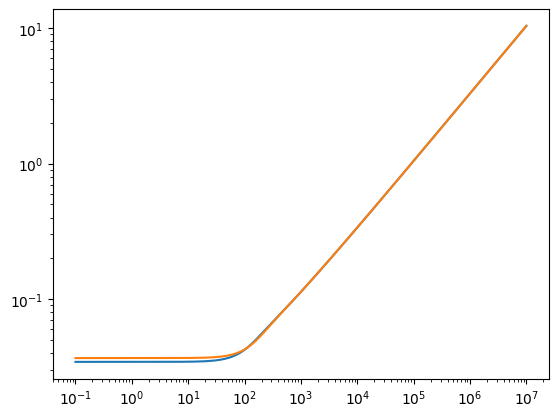

In [3]:
# visualiza os resultados
# parte real
plt.loglog(f, 1e3 * np.real(z1), f, 1e3 * np.real(z2))
plt.show()

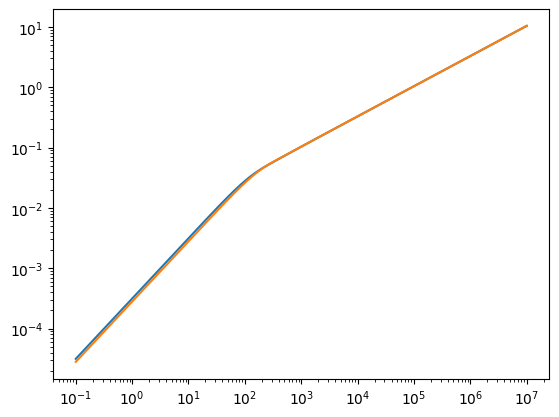

In [4]:
# visualiza os resultados
# parte imag
plt.loglog(f,  1e3 *  np.imag(z1), f,  1e3 *  np.imag(z2) )
plt.show()

In [5]:
dz_re = (np.real(z1)- np.real(z2)) / np.real(z2)
dz_im = (np.imag(z1)- np.imag(z2)) / np.imag(z2)

In [6]:
np.max(dz_re)

np.float64(0.019577075581870832)

In [7]:
np.max(dz_im)

np.float64(0.12199360347081371)